#### Create cell-type specific pseudobulked count matrices 

In [1]:
import scanpy as sc 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
plots_dir = "pseudobulk_analysis_plots/"

In [4]:
def filter_features_by_cell_fraction(adata, min_fraction):
    '''Keep only the features present in at least min_fraction of cells'''
    # compute fraction of cells with non-zero counts per feature
    gene_mask = np.array((adata.X > 0).sum(axis=0)).flatten() / adata.n_obs >= min_fraction
    
    # subsetting
    adata_filtered = adata[:, gene_mask].copy()
    print(f"Kept {adata_filtered.n_vars} features out of {adata.n_vars} ({min_fraction*100}% minimum cells)")
    return adata_filtered

In [5]:
%%time
adata = sc.read_h5ad("../07_final_ATAC.h5ad")
adata

CPU times: user 4.56 s, sys: 27.6 s, total: 32.2 s
Wall time: 32.2 s


AnnData object with n_obs × n_vars = 690044 × 654221
    obs: 'ATAC_barcode', 'sample_id', 'leiden', 'donor_id', 'study', 'age_status', 'age', 'sex', 'region', 'disease_binary', 'technology', 'fragment_file', 'full_path', 'file', 'nfrag', 'tsse', 'cell_type', 'tech_plus_study', 'age_group', 'decade', 'final_cell_type', 'cell_or_nuclei', 'disease'
    var: 'count', 'selected'
    uns: 'age_status_colors', 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'spectral_eigenvalue', 'study_colors'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [6]:
Counter(adata.obs.cell_type)

Counter({'Cardiomyocyte': 291398,
         'Fibroblast': 139237,
         'Endothelial': 115270,
         'Myeloid': 56991,
         'Pericyte': 54540,
         'Lymphoid': 18802,
         'vSMC': 5904,
         'Neuronal': 3365,
         'Epicardial': 2299,
         'Mast': 1303,
         'Adipocyte': 935})

In [7]:
# make sure to use the raw counts
adata.X.sum(axis = 1)

matrix([[1382],
        [1345],
        [1268],
        ...,
        [1505],
        [3174],
        [2101]], dtype=uint64)

#### Extract the metadata

In [8]:
adata_metadata = adata.obs[["age", "age_group", "age_status", 
                            "donor_id", 
                            "sex", 
                            "technology", "study", "tech_plus_study", 
                            "disease_binary", "disease"]].reset_index(drop = True).drop_duplicates().reset_index(drop = True)

In [9]:
output_dir = "raw_pseudobulked_matrices/"
os.makedirs(output_dir, exist_ok = True)

In [10]:
cell_type_key = "final_cell_type"
cell_types_list = adata.obs[cell_type_key].unique()
cell_types_list
donor_key = "donor_id"

### Perform pseudobulking per donor per cell type

- Include number of cells as a covariate
- Use fragment threshold of 300000

In [11]:
frag_threshold = 300000

In [12]:
cell_type = "Myeloid"

In [13]:
cell_type_adata = adata[adata.obs[cell_type_key] == cell_type, :]

In [14]:
filt_cell_type_adata = filter_features_by_cell_fraction(cell_type_adata, min_fraction=0.01)

Kept 57241 features out of 654221 (1.0% minimum cells)


In [15]:
counts = Counter(filt_cell_type_adata.obs["donor_id"])

# convert to DataFrame
df_counts = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index()
df_counts = df_counts.rename(columns={"index": "donor_id", "count": "cell_count"})

In [16]:
pseudobulked_adata = sc.get.aggregate(filt_cell_type_adata, by = donor_key, func = "sum")

In [17]:
pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])

In [18]:
pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])
pseudobulked_count_matrix.shape

(106, 57241)

In [19]:
total_counts = pseudobulked_count_matrix.sum(axis = 1)

In [20]:
filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > frag_threshold, ]

In [21]:
filt_pseudobulked_adata = pseudobulked_adata[total_counts > frag_threshold, :]
filt_pseudobulked_adata.obs

,age,age_group,age_status,sex,technology,study,tech_plus_study,disease_binary,disease
donor_id,,,,,,,,,
Ameen 2022:GSM5495104_F19_v2,19.0,fetal,fetal,female,10X_ATAC,Ameen 2022,10X_ATAC_Ameen 2022,N,ND
ENCODE v4 (Snyder):ENCFF775ANN,15.0,fetal,fetal,female,Multiome-v1,ENCODE v4 (Snyder),Multiome-v1_ENCODE v4 (Snyder),N,ND
ENCODE v4 (Snyder):ENCSR002SMQ,68.0,old,postnatal,male,Multiome-v1,ENCODE v4 (Snyder),Multiome-v1_ENCODE v4 (Snyder),N,ND
ENCODE v4 (Snyder):ENCSR008CVR,67.0,old,postnatal,male,Multiome-v1,ENCODE v4 (Snyder),Multiome-v1_ENCODE v4 (Snyder),N,ND
ENCODE v4 (Snyder):ENCSR012APQ,66.0,old,postnatal,male,Multiome-v1,ENCODE v4 (Snyder),Multiome-v1_ENCODE v4 (Snyder),N,ND
...,...,...,...,...,...,...,...,...,...
Penn:K1647,34.0,young,postnatal,male,10X_ATAC,Penn,10X_ATAC_Penn,N,ND
Penn:K1727,40.0,middle,postnatal,male,10X_ATAC,Penn,10X_ATAC_Penn,N,ND
Penn:ND15755,65.0,old,postnatal,male,10X_ATAC,Penn,10X_ATAC_Penn,N,ND


In [22]:
filt_pseudobulked_adata.shape

(81, 57241)

In [23]:
filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > frag_threshold, ]
filt_pseudobulked_count_matrix.shape

(81, 57241)

In [24]:
%%time 

frag_threshold = 300000
threshold_for_peak = 0.01

num_donors_per_cell_type = list()

for cell_type in cell_types_list:
    print(cell_type)
    cell_type_adata = adata[adata.obs[cell_type_key] == cell_type, :]

    # filter to peaks present in at least 0.1% of cells
    filt_cell_type_adata = filter_features_by_cell_fraction(cell_type_adata, min_fraction=0.01)

    counts = Counter(filt_cell_type_adata.obs["donor_id"])
    # convert to df
    df_counts = pd.DataFrame.from_dict(counts, orient="index", columns=["count"]).reset_index()
    df_counts = df_counts.rename(columns={"index": "donor_id", "count": "cell_count"})
    
    pseudobulked_adata = sc.get.aggregate(filt_cell_type_adata, by = donor_key, func = "sum")
    pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
    pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
    pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])
    pseudobulked_adata.obs = pseudobulked_adata.obs.merge(df_counts, on = donor_key, how = "inner")

    pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])

    total_counts = pseudobulked_count_matrix.sum(axis = 1)

    # keep only those above the UMI threshold (50K)
    filt_pseudobulked_count_matrix = pseudobulked_count_matrix.loc[total_counts > frag_threshold, ]
    filt_pseudobulked_adata = pseudobulked_adata[total_counts > frag_threshold, :]
    
    print(filt_pseudobulked_count_matrix.shape)
    
    num_donors = filt_pseudobulked_count_matrix.shape[0]
    num_donors_per_cell_type.append(num_donors)
    
    filt_pseudobulked_count_matrix.index = filt_pseudobulked_adata.obs_names.astype(str)
    filt_pseudobulked_count_matrix.columns = filt_pseudobulked_adata.var.index
    filt_pseudobulked_count_matrix.to_csv(output_dir + cell_type + "_count_matrix.csv")

    # get corresponding metadata
    metadata = filt_pseudobulked_adata.obs
    #metadata.index = metadata.donor_id.astype(str)
    metadata.to_csv(output_dir + cell_type + "_metadata.csv")

Adipocyte
Kept 98711 features out of 654221 (1.0% minimum cells)
(1, 98711)
Cardiomyocyte
Kept 130862 features out of 654221 (1.0% minimum cells)
(104, 130862)
Endothelial
Kept 51485 features out of 654221 (1.0% minimum cells)
(103, 51485)
Epicardial
Kept 55236 features out of 654221 (1.0% minimum cells)
(6, 55236)
Fibroblast
Kept 73622 features out of 654221 (1.0% minimum cells)
(106, 73622)
Pericyte
Kept 52732 features out of 654221 (1.0% minimum cells)
(88, 52732)
Myeloid
Kept 57241 features out of 654221 (1.0% minimum cells)
(81, 57241)
Lymphoid
Kept 31502 features out of 654221 (1.0% minimum cells)
(18, 31502)
Mast
Kept 44834 features out of 654221 (1.0% minimum cells)
(1, 44834)
Neuronal
Kept 50349 features out of 654221 (1.0% minimum cells)
(1, 50349)
vSMC
Kept 45632 features out of 654221 (1.0% minimum cells)
(8, 45632)
CPU times: user 2min 56s, sys: 1min 37s, total: 4min 33s
Wall time: 4min 34s


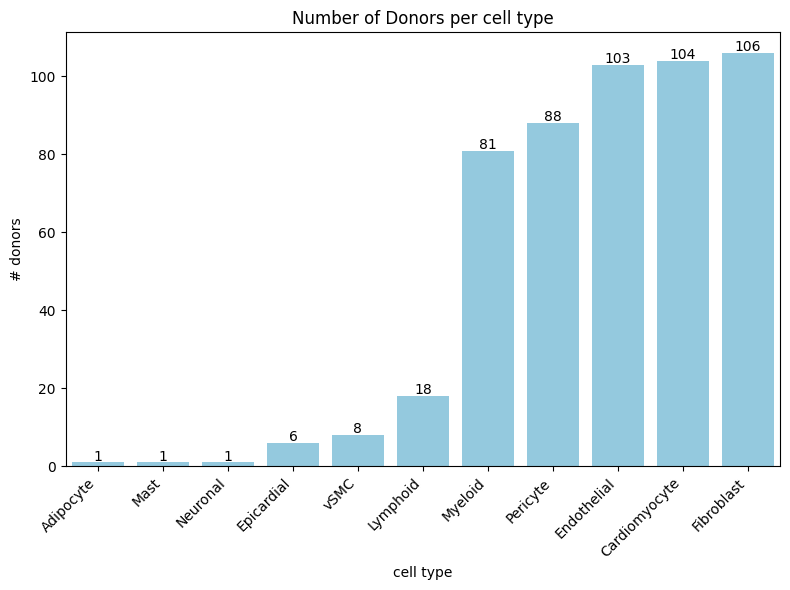

In [25]:
num_donors_per_cell_type_df = pd.DataFrame({
    "cell_type": cell_types_list,
    "num_donors": num_donors_per_cell_type
})

num_donors_per_cell_type_df['cell_type'] = num_donors_per_cell_type_df['cell_type'].astype(str)

# sort in ascending order
num_donors_per_cell_type_df = num_donors_per_cell_type_df.sort_values(
    by="num_donors", ascending=True
)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=num_donors_per_cell_type_df,
    x='cell_type',
    y='num_donors',
    color="skyblue"
)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2.,   
        p.get_height() + 0.5,             
        int(p.get_height()),             
        ha='center'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel('# donors')
plt.xlabel('cell type')
plt.title('Number of Donors per cell type')

plt.tight_layout()
plt.savefig(plots_dir + "num_donors_per_cell_type.pdf")
plt.show()

### Also create a fully pseudobulked sample, without separating by cell type

In [26]:
%%time
pseudobulked_adata = sc.get.aggregate(adata, by = donor_key, func = "sum")
pseudobulked_adata.obs = pseudobulked_adata.obs.merge(adata_metadata, on = donor_key, how = "inner")
pseudobulked_adata.obs_names = pseudobulked_adata.obs[donor_key].astype(str)
#pseudobulked_adata.obs = pseudobulked_adata.obs.drop(columns = ["donor_id"])

pseudobulked_count_matrix = pd.DataFrame(pseudobulked_adata.layers['sum'])
pseudobulked_count_matrix.index = pseudobulked_adata.obs_names.astype(str)
pseudobulked_count_matrix.columns = pseudobulked_adata.var.index
pseudobulked_count_matrix.to_csv(output_dir  + "pseudobulked_count_matrix.csv")

# get corresponding metadata
metadata = pseudobulked_adata.obs
metadata.to_csv(output_dir + "pseudobulked_metadata.csv")

CPU times: user 2min 29s, sys: 48 s, total: 3min 17s
Wall time: 3min 17s
